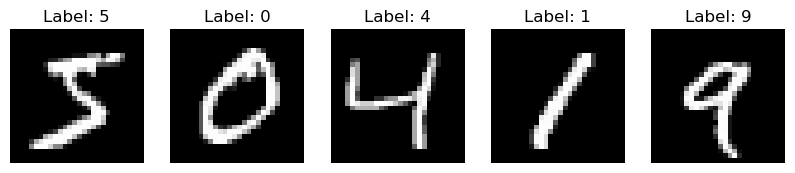

In [2]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.show()

In [3]:
import time

from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

clf = SVC()

start_time = time.time()
scores_original = cross_val_score(clf, X, y, n_jobs=-1)
end_time = time.time()

time_original = end_time - start_time

print(f"Original data scores: {scores_original.mean():.2f} ± {scores_original.std():.2f}")
print(f"Time taken for original data: {time_original:.2f} seconds")

Original data scores: 0.98 ± 0.00
Time taken for original data: 763.85 seconds


In [4]:
from sklearn.decomposition import PCA

pca_10 = PCA(n_components=10)
pca_30 = PCA(n_components=30)
pca_50 = PCA(n_components=50)
pca_100 = PCA(n_components=100)

X_10 = pca_10.fit_transform(X)
X_30 = pca_30.fit_transform(X)
X_50 = pca_50.fit_transform(X)
X_100 = pca_100.fit_transform(X)

explained_var_10 = pca_10.explained_variance_ratio_.sum() * 100
explained_var_30 = pca_30.explained_variance_ratio_.sum() * 100
explained_var_50 = pca_50.explained_variance_ratio_.sum() * 100
explained_var_100 = pca_100.explained_variance_ratio_.sum() * 100

print(f"Explained variance with 10 components: {explained_var_10:.2f}%")
print(f"Explained variance with 30 components: {explained_var_30:.2f}%")
print(f"Explained variance with 50 components: {explained_var_50:.2f}%")
print(f"Explained variance with 100 components: {explained_var_100:.2f}%")

Explained variance with 10 components: 48.92%
Explained variance with 30 components: 73.16%
Explained variance with 50 components: 82.54%
Explained variance with 100 components: 91.46%


In [5]:
start_time = time.time()
scores_10 = cross_val_score(clf, X_10, y, n_jobs=-1)
time_10 = time.time() - start_time

start_time = time.time()
scores_30 = cross_val_score(clf, X_30, y, n_jobs=-1)
time_30 = time.time() - start_time

start_time = time.time()
scores_50 = cross_val_score(clf, X_50, y, n_jobs=-1)
time_50 = time.time() - start_time

start_time = time.time()
scores_100 = cross_val_score(clf, X_100, y, n_jobs=-1)
time_100 = time.time() - start_time

print(f"Scores with 10 components: {scores_10.mean():.2f} ± {scores_10.std():.2f}")
print(f"Time taken for 10 components: {time_10:.2f} seconds")
print(f"Scores with 30 components: {scores_30.mean():.2f} ± {scores_30.std():.2f}")
print(f"Time taken for 30 components: {time_30:.2f} seconds")
print(f"Scores with 50 components: {scores_50.mean():.2f} ± {scores_50.std():.2f}")
print(f"Time taken for 50 components: {time_50:.2f} seconds")
print(f"Scores with 100 components: {scores_100.mean():.2f} ± {scores_100.std():.2f}")
print(f"Time taken for 100 components: {time_100:.2f} seconds")

Scores with 10 components: 0.94 ± 0.00
Time taken for 10 components: 45.15 seconds
Scores with 30 components: 0.98 ± 0.00
Time taken for 30 components: 61.61 seconds
Scores with 50 components: 0.98 ± 0.00
Time taken for 50 components: 100.34 seconds
Scores with 100 components: 0.98 ± 0.00
Time taken for 100 components: 162.72 seconds


In [6]:
import pandas as pd

results = {
    "Data": [
        "Original",
        "PCA (10 components)",
        "PCA (30 components)",
        "PCA (50 components)",
        "PCA (100 components)"
    ],
    "Mean Accuracy": [
        scores_original.mean(),
        scores_10.mean(),
        scores_30.mean(),
        scores_50.mean(),
        scores_100.mean()
    ],
    "Std Accuracy": [
        scores_original.std(),
        scores_10.std(),
        scores_30.std(),
        scores_50.std(),
        scores_100.std()
    ],
    "Time (s)": [
        time_original,
        time_10,
        time_30,
        time_50,
        time_100
    ]
}

df_results = pd.DataFrame(results)
print("\nResults Summary:")
print(df_results)


Results Summary:
                   Data  Mean Accuracy  Std Accuracy    Time (s)
0              Original       0.977971      0.002110  763.849870
1   PCA (10 components)       0.935286      0.002889   45.150392
2   PCA (30 components)       0.979843      0.001363   61.611458
3   PCA (50 components)       0.982414      0.001669  100.343880
4  PCA (100 components)       0.982314      0.001727  162.718397


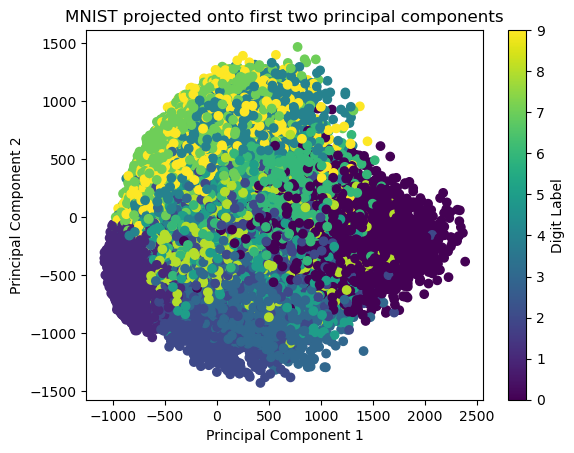

In [8]:
plt.figure()
scatter = plt.scatter(X_10[:, 0], X_10[:, 1], c=y.astype(int))
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('MNIST projected onto first two principal components')
plt.colorbar(scatter, label='Digit Label')
plt.show()